<a href="https://colab.research.google.com/github/sahanameka7-rgb/GenAIDeveloper/blob/main/LangGraph_Basics_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END


In [2]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    result: int

def add_node(state: AgentState) -> AgentState:
    state["result"] = state["number1"] + state["number2"]
    return state

def subtract_node(state: AgentState) -> AgentState:
    state["result"] = state["number1"] - state["number2"]
    return state

def multiply_node(state: AgentState) -> AgentState:
    state["result"] = state["number1"] * state["number2"]
    return state

def divide_node(state: AgentState) -> AgentState:
    state["result"] = state["number1"] / state["number2"]
    return state

def decide_next_node(state: AgentState) -> str:
    if state["operation"] == "add":
        return "add_node"
    elif state["operation"] == "subtract":
        return "subtract_node"
    elif state["operation"] == "multiply":
        return "multiply_node"
    elif state["operation"] == "divide":
        return "divide_node"

graph = StateGraph(AgentState)

graph.add_node("add_node", add_node)
graph.add_node("subtract_node", subtract_node)
graph.add_node("multiply_node", multiply_node)
graph.add_node("divide_node", divide_node)

graph.add_conditional_edges(START, decide_next_node, {
    "add_node": "add_node",
    "subtract_node": "subtract_node",
    "multiply_node": "multiply_node",
    "divide_node": "divide_node"
})

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)
graph.add_edge("multiply_node", END)
graph.add_edge("divide_node", END)

app = graph.compile()
result = app.invoke({"number1": 10, "operation": "add", "number2": 20})
print(result)


{'number1': 10, 'operation': 'add', 'number2': 20, 'result': 30}


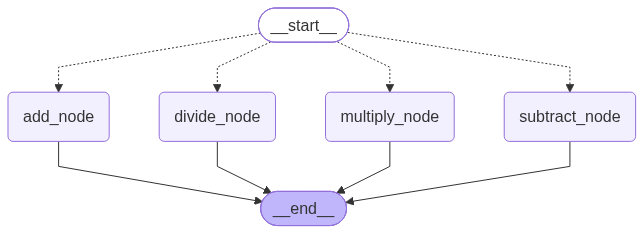

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))